In [6]:
from typing import TypedDict

class State(TypedDict):
    graph_info: str

In [7]:
def start_play(state: State): 
    print("Start play node has been called")
    return { "graph_info": state["graph_info"] + "I am planning to play "}

def cricket(state: State):
    print("Cricket node has been called")
    return { "graph_info": state["graph_info"] + "I am playing cricket"}

def football(state: State):
    print("Football node has been called")
    return { "graph_info": state["graph_info"] + "I am playing football"}


In [8]:
import random
from typing import Literal

def random_activity(state: State) -> Literal["cricket", "football"]:
    return random.choice(["cricket", "football"])



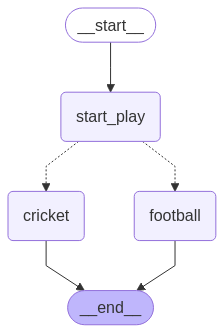

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build the graph
graph = StateGraph(State)

# Add nodes
graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("football", football)

# Schedule the flow of the graph
graph.add_edge(START, "start_play")
graph.add_conditional_edges(
    "start_play",
    random_activity
)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

# Compile the graph
compiled_graph = graph.compile()

# View the graph
compiled_graph.get_graph().draw_mermaid_png()

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [26]:
compiled_graph.invoke({"graph_info": "My name is Mo, "})

Start play node has been called
Cricket node has been called


{'graph_info': 'My name is Mo, I am planning to playI am playing cricket'}